In [5]:
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

from audio.capture import audio_capture
from audio.vad import VAD
from config import SAMPLE_RATE, FRAME_MS, VAD_AGGRESSIVENESS

In [6]:
DURATION = 5

stream = audio_capture()
frames = []
num_frames = int(DURATION * 1000 / FRAME_MS)

for i, frame in enumerate(stream):
    frames.append(frame)

    if i >= num_frames - 1:
        break

audio = np.concatenate(frames)

In [7]:
blocksize = SAMPLE_RATE * FRAME_MS // 1000

audio_frames = []

for i in range(0, len(audio), blocksize):
    frame = audio[i:i + blocksize]

    # skip incomplete final frame
    if len(frame) == blocksize:
        audio_frames.append(frame)

In [8]:
vad = VAD(VAD_AGGRESSIVENESS)

speech_flags=[]

for frame in audio_frames:
    is_speech = vad.is_speech(frame.tobytes(), SAMPLE_RATE)
    speech_flags.append(is_speech)

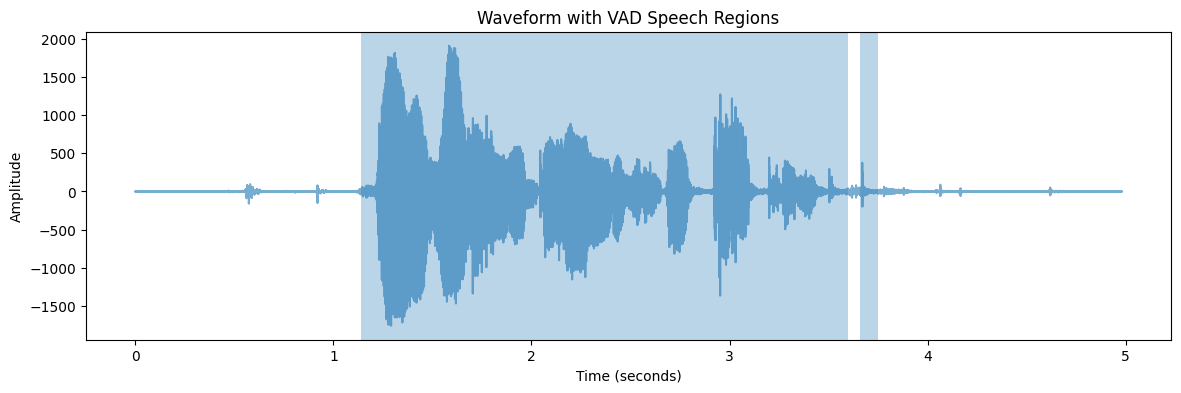

In [9]:
time_axis = np.arange(len(audio)) / SAMPLE_RATE
plt.figure(figsize=(14, 4))
plt.plot(time_axis, audio, alpha=0.6)

for i, is_speech in enumerate(speech_flags):

    if is_speech:

        start = i * FRAME_MS / 1000
        end = (i + 1) * FRAME_MS / 1000

        plt.axvspan(start, end, alpha=0.3)

plt.title("Waveform with VAD Speech Regions")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()